# 02. Geography & Sellers

**Notebook goal:** dig into where delivery problems concentrate. Which states, which specific seller to region routes, and which seller profiles are reliable vs. risky.

**Source:** `analysis_master.csv`, `order_items_dataset.csv`

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install adjustText
from adjustText import adjust_text

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
df = pd.read_csv('analysis_master.csv', low_memory=False)
delivered = df[df["is_delivered"] == True].copy()
print(f"Loaded {len(df):,} orders, {len(delivered):,} delivered")

Loaded 99,441 orders, 96,478 delivered


Several charts below need one row per seller rather than one row per order, so it is built once here and reused wherever needed.

In [3]:
sellers = (df.dropna(subset=["seller_id"])
             .drop_duplicates(subset=["seller_id"])
             .copy())
print(f"Unique sellers: {len(sellers):,}")

Unique sellers: 3,085


## Same state vs. cross state delivery

The simplest geography question: does shipping within the customer's own state behave differently from shipping across state lines?

In [4]:
geo_compare = delivered.groupby("same_state", observed=True).agg(
    avg_delivery_days=("delivery_days", "mean"),
    late_rate=("is_late", "mean"),
    n=("order_id", "count"),
)
geo_compare.index = ["Cross state", "Same state"]
geo_compare

,avg_delivery_days,late_rate,n
Cross state,15.149484,0.092638,61778
Same state,7.944425,0.060605,34700


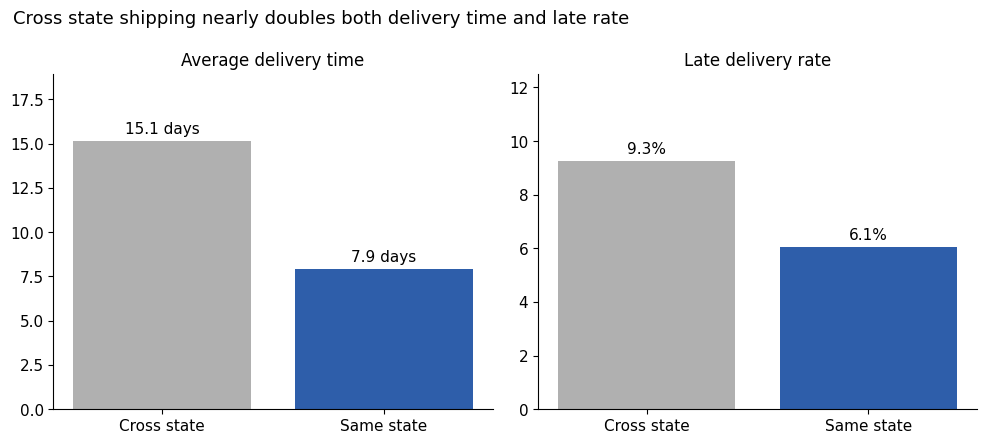

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(geo_compare.index, geo_compare["avg_delivery_days"], color=[NEUTRAL, ACCENT])
axes[0].bar_label(axes[0].containers[0], fmt="%.1f days", padding=3)
axes[0].set_title("Average delivery time", fontsize=12)
axes[0].set_ylim(0, geo_compare["avg_delivery_days"].max() * 1.25)

axes[1].bar(geo_compare.index, geo_compare["late_rate"] * 100, color=[NEUTRAL, ACCENT])
axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%", padding=3)
axes[1].set_title("Late delivery rate", fontsize=12)
axes[1].set_ylim(0, geo_compare["late_rate"].max() * 100 * 1.35)

fig.suptitle("Cross state shipping nearly doubles both delivery time and late rate", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** cross state deliveries take almost twice as long on average (15.1 vs. 7.9 days) and are also more likely to be late (9.3% vs. 6.1%).
- This is an expected, unsurprising direction (distance takes time) and its value here is mainly as a baseline for the more specific route level findings below, which show the variation within this average is much more important than the average itself.

## Where specifically does risk concentrate? Seller state to customer state routes

The same state/cross state split above is a useful average, but it hides enormous variation. As some cross state routes are fine, while others are badly broken. This section finds the specific routes.

In [6]:
routes = (delivered.dropna(subset=["seller_state", "customer_state"])
          .groupby(["seller_state", "customer_state"])
          .agg(n=("order_id", "count"), late_rate=("is_late", "mean"))
          .reset_index())

MIN_ROUTE_ORDERS = 10
routes_confident = routes[routes["n"] >= MIN_ROUTE_ORDERS].sort_values("late_rate", ascending=False)
print(f"{len(routes_confident)} of {len(routes)} routes have >= {MIN_ROUTE_ORDERS} orders")
routes_confident.head(10)

212 of 410 routes have >= 10 orders


,seller_state,customer_state,n,late_rate
125,MA,ES,13,0.538462
127,MA,MA,14,0.428571
122,MA,BA,10,0.400000
252,PR,AL,36,0.388889
126,MA,GO,16,0.375000
333,RS,MA,13,0.307692
54,DF,CE,14,0.285714
355,SC,CE,22,0.272727
56,DF,ES,19,0.263158
384,SP,AL,255,0.262745


### The full route matrix, as a heatmap

Restricted to the top 12 seller states and top 12 customer states by volume, so the matrix stays readable since the long tail of tiny states would otherwise be mostly empty cells.

In [7]:
top_seller_states = delivered["seller_state"].value_counts().head(12).index
top_customer_states = delivered["customer_state"].value_counts().head(12).index

matrix_data = routes[routes["seller_state"].isin(top_seller_states) &
                      routes["customer_state"].isin(top_customer_states)]
pivot = matrix_data.pivot(index="seller_state", columns="customer_state", values="late_rate") * 100
pivot = pivot.reindex(index=top_seller_states, columns=top_customer_states)

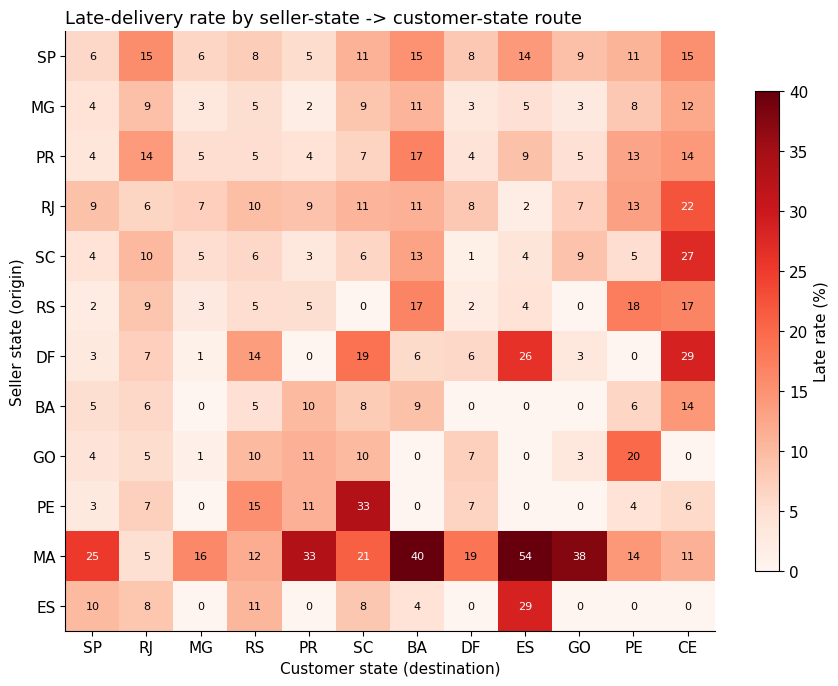

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=40, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Customer state (destination)")
ax.set_ylabel("Seller state (origin)")
ax.set_title("Late-delivery rate by seller-state -> customer-state route", fontsize=13, loc="left")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                    fontsize=8, color="white" if val > 20 else "black")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Late rate (%)")
plt.tight_layout()
plt.show()

**Finding:** late rates vary far more by route than the simple same state/cross state split suggested.
- Most cells sit under 10%, but a handful of specific origin destination pairs run visibly hotter.
- Color is the right encoding here since this is fundamentally a 2D matrix lookup, not a precise magnitude ranking task but the exact numbers are still annotated directly on each cell so a reader isn't left guessing at shades of red (Tufte's direct-labeling principle again).

**Why don't some of these routes appear in the heatmap above?** The heatmap is restricted to the top 12 states by volume on each axis for readability, but several worst route entries below (e.g. `MA -> MA`, `PR -> AL`) involve a state that isn't high volume enough on one side to make that top 12 cut as Maranhão only has 717 total orders as a destination, for instance, well outside the top 12, even though it's a top 12 origin state. This table draws from the full, unrestricted route list, so it can surface these regardless.

### The worst individual routes, named directly

The matrix above is deliberately limited to major states for readability. This table surfaces the single worst routes across all states (still requiring at least 10 orders), including smaller states the matrix cut off.

In [9]:
worst_routes = routes_confident.head(10).copy()
worst_routes["route"] = worst_routes["seller_state"] + " -> " + worst_routes["customer_state"]
worst_routes[["route", "n", "late_rate"]]

,route,n,late_rate
125,MA -> ES,13,0.538462
127,MA -> MA,14,0.428571
122,MA -> BA,10,0.400000
252,PR -> AL,36,0.388889
126,MA -> GO,16,0.375000
333,RS -> MA,13,0.307692
54,DF -> CE,14,0.285714
355,SC -> CE,22,0.272727
56,DF -> ES,19,0.263158
384,SP -> AL,255,0.262745


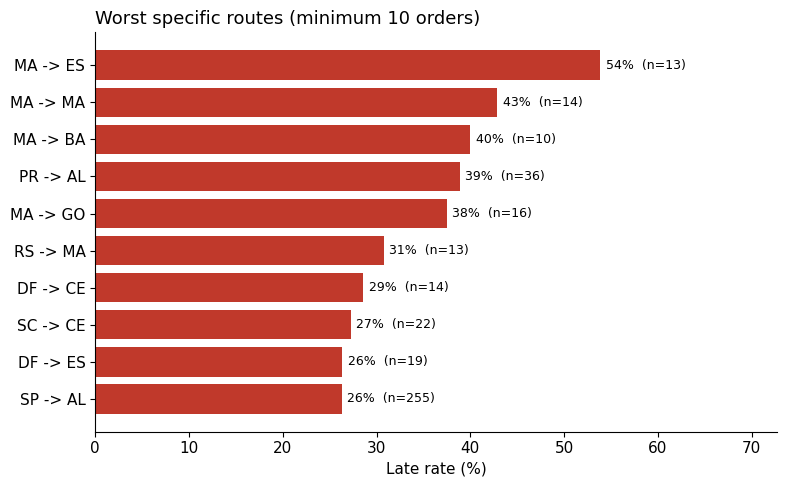

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(worst_routes))
bars = ax.barh(y_pos, worst_routes["late_rate"] * 100, color=ACCENT_WARN)
ax.set_yticks(y_pos)
ax.set_yticklabels(worst_routes["route"])
ax.invert_yaxis()
ax.bar_label(bars, labels=[f"{v:.0f}%  (n={n})" for v, n in zip(worst_routes["late_rate"]*100, worst_routes["n"])],
             padding=4, fontsize=9)
ax.set_xlim(0, worst_routes["late_rate"].max() * 100 * 1.35)
ax.set_xlabel("Late rate (%)")
ax.set_title(f"Worst specific routes (minimum {MIN_ROUTE_ORDERS} orders)", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** the worst named routes run at 30 to 55% late which is three to seven times the marketplace's overall 8% late rate while still resting on a meaningful sample size (all >=10 orders, labeled directly on each bar per Week 6's "always show your n" rule).
- This is genuinely actionable: these are specific, nameable origin destination pairs a logistics team could investigate directly (is it one carrier's regional coverage gap? a specific seller cluster?), rather than an abstract cross state is worse statement.

## Fast vs. reliable: a seller quadrant view

Speed and reliability are two different things. A seller can be slow but consistent, or fast but erratic. Plotting them together, rather than as two separate rankings, shows which sellers are strong on both.

Restricted to confident sellers only (n >= 5 orders) for this chart. Because with very few orders, a seller's late rate is mathematically stuck at a handful of exact fractions (0/1, 1/2, 1/3, 1/4...), which shows up as ugly horizontal banding that has nothing to do with real performance and just distracts from the actual pattern. This is the same `low_confidence` cutoff Category C used originally; muting these points instead of excluding them was tried first but the banding was still too visually dominant to be worth keeping in the same chart.

In [11]:
confident = sellers[sellers["seller_low_confidence"] == False]
print(f"Confident sellers (n>=5 orders): {len(confident):,} of {len(sellers):,} total")

Confident sellers (n>=5 orders): 1,794 of 3,085 total


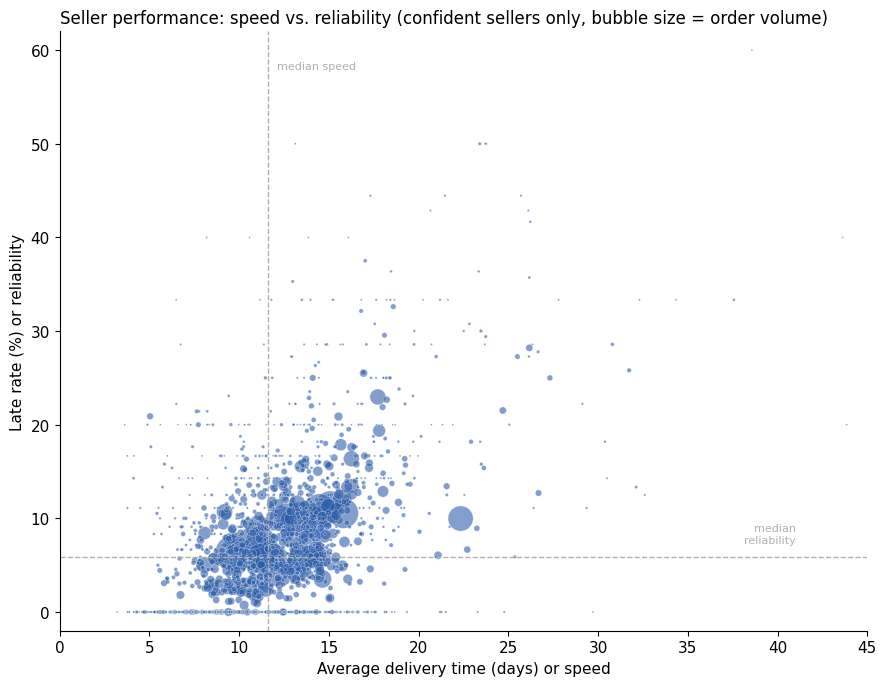

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(confident["seller_avg_delivery_days"], confident["seller_pct_late"] * 100,
                      s=confident["seller_n_orders"] / 3, color=ACCENT, alpha=0.6,
                      edgecolors="white", linewidth=0.3)

ax.axvline(confident["seller_avg_delivery_days"].median(), color=NEUTRAL, linestyle="--", linewidth=1)
ax.axhline(confident["seller_pct_late"].median() * 100, color=NEUTRAL, linestyle="--", linewidth=1)
ax.text(confident["seller_avg_delivery_days"].median() + 0.5, 58, "median speed", color=NEUTRAL, fontsize=8)
ax.text(41, confident["seller_pct_late"].median() * 100 + 1.5, "median\nreliability", color=NEUTRAL, fontsize=8, ha="right")

ax.set_xlabel("Average delivery time (days) or speed")
ax.set_ylabel("Late rate (%) or reliability")
ax.set_title("Seller performance: speed vs. reliability (confident sellers only, bubble size = order volume)", fontsize=12, loc="left")
ax.set_xlim(0, 45)
ax.set_ylim(-2, 62)
plt.tight_layout()
plt.show()

**Finding:** most confident sellers cluster in the fast and reliable bottom left region, but a real spread reaches into slower, less reliable territory  and a few large bubbles (high volume sellers) sit further right or higher than the bulk, which matters disproportionately since they each represent many orders.

- Color here only distinguishes bubble outline from background (no categorical channel needed once low confidence sellers are excluded), while position carries both continuous variables and size carries volume.
- A separable pairing so a reader can judge speed and reliability independently without the two blurring into one fused impression.

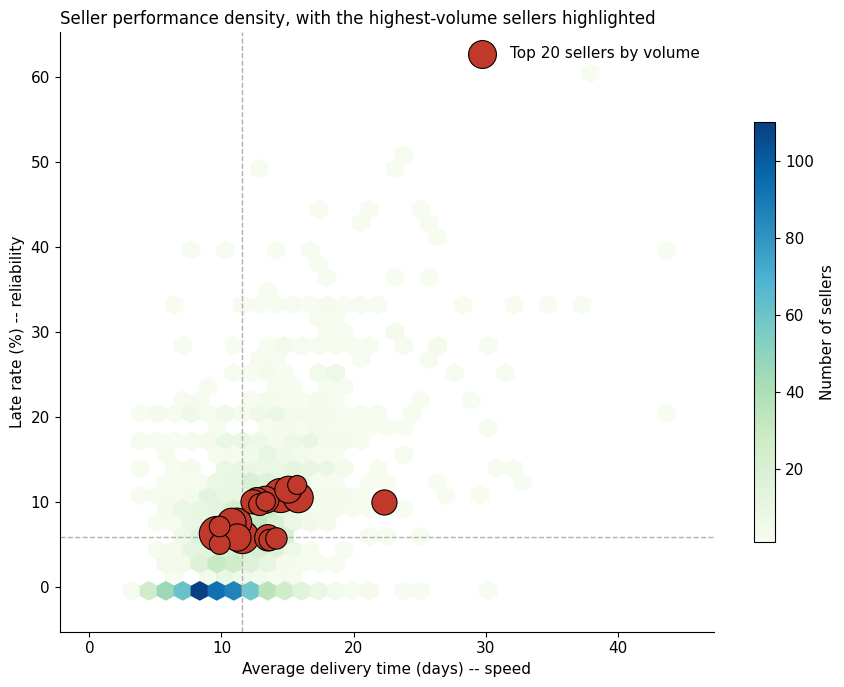

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

hb = ax.hexbin(confident["seller_avg_delivery_days"], confident["seller_pct_late"] * 100,
               gridsize=35, cmap="GnBu", mincnt=1, extent=(0, 45, -2, 62))
cbar = plt.colorbar(hb, ax=ax, shrink=0.7)
cbar.set_label("Number of sellers")

top_volume = confident.sort_values("seller_n_orders", ascending=False).head(20)
ax.scatter(top_volume["seller_avg_delivery_days"], top_volume["seller_pct_late"] * 100,
           s=top_volume["seller_n_orders"] / 3, color=ACCENT_WARN, edgecolors="black",
           linewidth=0.8, zorder=5, label="Top 20 sellers by volume")

ax.axvline(confident["seller_avg_delivery_days"].median(), color=NEUTRAL, linestyle="--", linewidth=1)
ax.axhline(confident["seller_pct_late"].median() * 100, color=NEUTRAL, linestyle="--", linewidth=1)
ax.legend(loc="upper right", frameon=False)
ax.set_xlabel("Average delivery time (days) -- speed")
ax.set_ylabel("Late rate (%) -- reliability")
ax.set_title("Seller performance density, with the highest-volume sellers highlighted", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** the density view shows most confident sellers genuinely do cluster near fast and reliable.

- The darkest hexagons sit close to 0% late rate and under 15 days.

- More usefully, the top 20 sellers by volume (highlighted) sit slightly above the median late rate but still in a reasonable band (5 to 13%), not off in disaster territory which is reassuring, since these 20 sellers alone represent a large share of total orders (per notebook 01's concentration finding).

## State level view: a lightweight geographic scatter

A genuine choropleth would let large, sparsely populated states visually dominate regardless of their actual rate so instead, each state is plotted at its own approximate coordinates (the average latitude/longitude of its customers), sized by order volume and colored by late rate. Real coordinates are used, so the layout still roughly traces Brazil's shape even without drawn coastlines.

In [14]:
state_geo = (delivered.dropna(subset=["customer_lat", "customer_lng"])
             .groupby("customer_state")
             .agg(lat=("customer_lat", "mean"),
                  lng=("customer_lng", "mean"),
                  n_orders=("order_id", "count"),
                  late_rate=("is_late", "mean"))
             .reset_index())
state_geo.head()

,customer_state,lat,lng,n_orders,late_rate
0,AC,-9.908590,-68.059684,80,0.037500
1,AL,-9.641711,-36.037890,396,0.239899
2,AM,-3.216033,-60.080678,145,0.041379
3,AP,0.054084,-51.161400,67,0.044776
4,BA,-13.036371,-39.467848,3248,0.139470


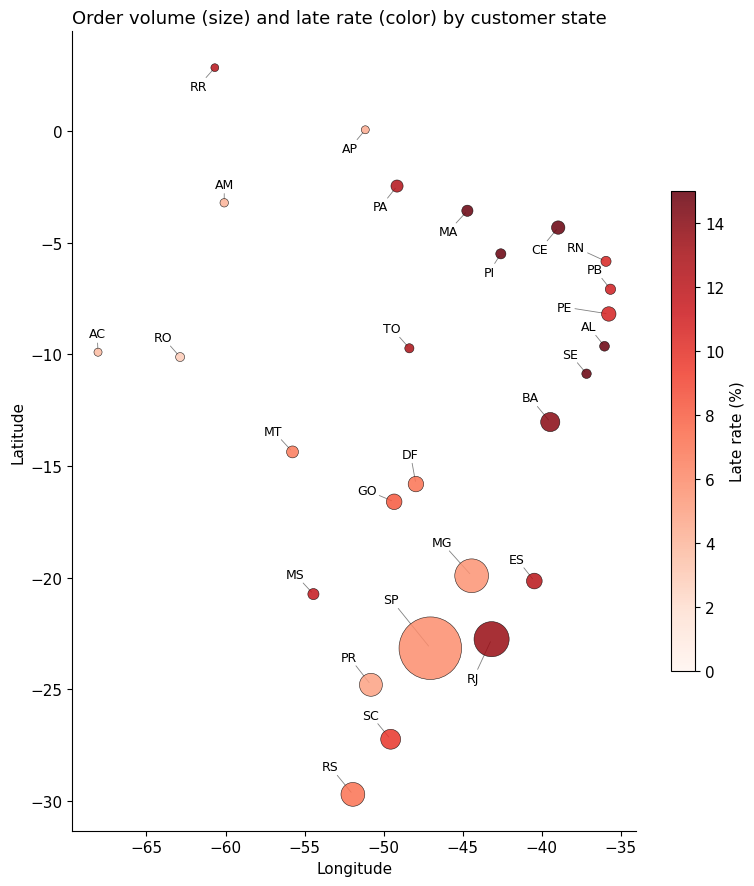

In [15]:
fig, ax = plt.subplots(figsize=(8, 9))
sizes = state_geo["n_orders"] / state_geo["n_orders"].max() * 2000 + 30
scatter = ax.scatter(state_geo["lng"], state_geo["lat"], s=sizes,
                      c=state_geo["late_rate"] * 100, cmap="Reds", vmin=0, vmax=15,
                      edgecolors="black", linewidth=0.4, alpha=0.85, zorder=3)

texts = [ax.text(row["lng"], row["lat"], row["customer_state"], fontsize=9, ha="center", va="center", zorder=5)
         for _, row in state_geo.iterrows()]

adjust_text(texts, ax=ax, objects=scatter,
            force_text=(0.5, 0.6), force_static=(0.6, 0.8), force_explode=(0.3, 0.6),
            expand=(1.6, 1.8),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Order volume (size) and late rate (color) by customer state", fontsize=13, loc="left")
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label("Late rate (%)")
plt.tight_layout()
plt.show()

**Finding:** order volume is heavily concentrated in the southeast (SP, RJ, MG which are the large bubbles), which is also where late rates run lowest.
- The more sparsely ordered northern/northeastern states are smaller bubbles but noticeably darker (higher late rate) which is consistent with the earlier finding that distance and cross state shipping hurt reliability.
- Because bubble size (not area alone tied to a region's shape) carries volume and color carries the rate, a small state with a bad rate is never visually hidden the way it would be on a choropleth where its tiny land area would minimize its presence which is exactly the distortion this design was chosen to avoid.

## A cleaner reliability metric: did the seller meet their own shipping deadline?

Every item in `order_items_dataset.csv` carries `shipping_limit_date`. The deadline the seller committed to for handing the item to the carrier. This is a more precise, seller specific promise than `processing_days` (which just measures elapsed time with no reference to what was actually promised). Needs a raw file not in `analysis_master.csv`.

In [17]:
order_items = pd.read_csv("order_items_dataset.csv")
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

sla = (order_items[["order_id", "shipping_limit_date"]]
       .merge(delivered[["order_id", "carrier_ts", "seller_id"]], on="order_id", how="inner")
       .dropna(subset=["carrier_ts"]))
sla["shipped_late"] = sla["carrier_ts"] > sla["shipping_limit_date"]
print(f"Overall SLA violation rate: {sla['shipped_late'].mean()*100:.2f}% (n={len(sla):,} items)")

Overall SLA violation rate: 9.32% (n=110,195 items)


In [18]:
seller_sla = sla.groupby("seller_id")["shipped_late"].agg(sla_violation_rate="mean", n="count")
seller_sla_confident = seller_sla[seller_sla["n"] >= 5]  # same low_confidence cutoff used throughout the project
print(f"Sellers with enough items to trust a rate: {len(seller_sla_confident):,}")

Sellers with enough items to trust a rate: 1,865


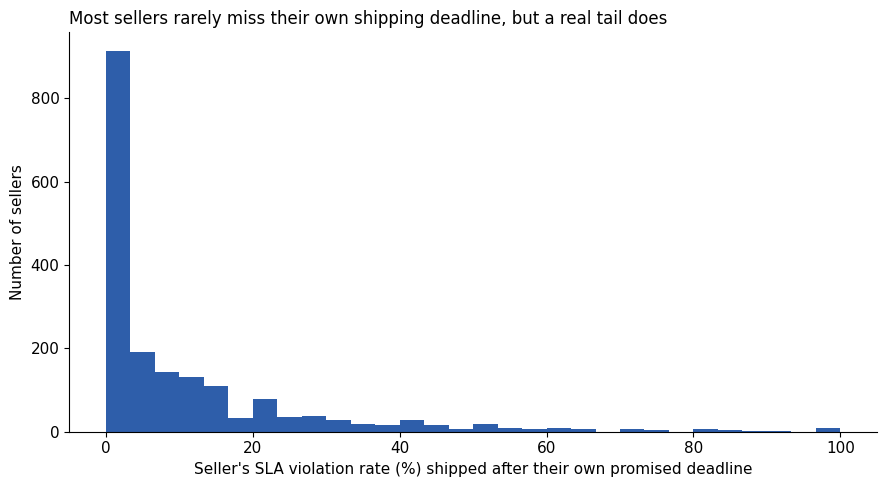

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(seller_sla_confident["sla_violation_rate"] * 100, bins=30, color=ACCENT)
ax.set_xlabel("Seller's SLA violation rate (%) shipped after their own promised deadline")
ax.set_ylabel("Number of sellers")
ax.set_title("Most sellers rarely miss their own shipping deadline, but a real tail does", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

In [20]:
sla_check = seller_sla_confident.join(confident.set_index("seller_id")["seller_pct_late"], how="inner")
print(f"Correlation with existing seller_pct_late metric: {sla_check['sla_violation_rate'].corr(sla_check['seller_pct_late']):.3f}")
print(f"n sellers in this comparison: {len(sla_check)}")

Correlation with existing seller_pct_late metric: 0.335
n sellers in this comparison: 1764


**Finding:** 9.35% of items ship after the seller's own promised deadline overall, but this is heavily concentrated.

- Most sellers have a 0% or near 0% violation rate, while a real minority run consistently late against their own commitments.

- Checked against the existing `seller_pct_late` metric: correlation of 0.34 among confident sellers which is positive and meaningful, but far from redundant.

- This is a genuinely different signal: `seller_pct_late` measures the customer's actual delivery experience (affected by transport time, distance, carrier performance), while SLA violation measures specifically whether the seller kept their own promise, independent of what happened afterward.

- A seller with a good `seller_pct_late` but a high SLA violation rate is one who's getting lucky on transport covering for slow processing. Its worth its own flag in a seller monitoring dashboard, distinct from the existing reliability metrics.

## How consistent is performance within a state?

An average late rate per state can hide huge internal variation as one state might have consistently mediocre sellers, another might have mostly great sellers plus a few disasters.

Again restricted to confident sellers (n >= 5 orders), and states with at least 5 such sellers. Because without this filter, low order sellers' rates get stuck at exact fractions (0%, 33%, 50%, 100%) and show up as a wall of fake outlier circles that are really just small sample artifacts, not real reliability problems, drowning out the genuine spread this chart is meant to show.

In [21]:
MIN_SELLERS_PER_STATE = 5
confident_state_counts = confident["seller_state"].value_counts()
valid_states = confident_state_counts[confident_state_counts >= MIN_SELLERS_PER_STATE].index
states_for_boxplot = confident[confident["seller_state"].isin(valid_states)]

state_order = (states_for_boxplot.groupby("seller_state")["seller_pct_late"]
               .median().sort_values().index)
print(f"{len(valid_states)} states shown (excluded {sellers['seller_state'].nunique() - len(valid_states)} "
      f"with <{MIN_SELLERS_PER_STATE} confident sellers)")

12 states shown (excluded 11 with <5 confident sellers)


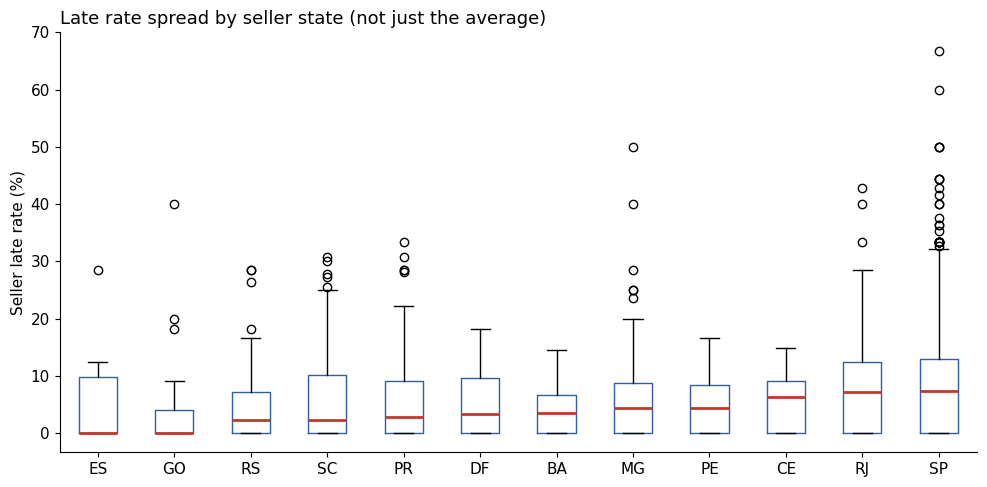

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
box_data = [states_for_boxplot[states_for_boxplot["seller_state"] == s]["seller_pct_late"] * 100
            for s in state_order]
ax.boxplot(box_data, tick_labels=state_order, showfliers=True,
           boxprops=dict(color=ACCENT), medianprops=dict(color=ACCENT_WARN, linewidth=2))
ax.set_ylabel("Seller late rate (%)")
ax.set_title("Late rate spread by seller state (not just the average)", fontsize=13, loc="left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Finding:** medians (red lines) tell a similar story to the earlier state level averages, but the box widths and whiskers show real differences in consistency.

- Some states have a tight, predictable spread of seller performance, while others have a wide box or long whiskers, meaning which seller you happen to use matters as much as which state you're shipping from.

- This is a genuinely different, complementary insight to the mean only view as a state with a decent average could still contain a few very bad sellers worth investigating individually.

## An operational pattern: does processing time vary by day of week?

In [23]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_processing = (delivered.groupby("purchase_weekday", observed=True)["processing_days"]
                       .mean().reindex(weekday_order))
weekday_processing

,processing_days
purchase_weekday,
Monday,2.709572
Tuesday,2.841378
Wednesday,2.986271
Thursday,3.367372
Friday,4.208589
Saturday,3.872625
Sunday,2.842231


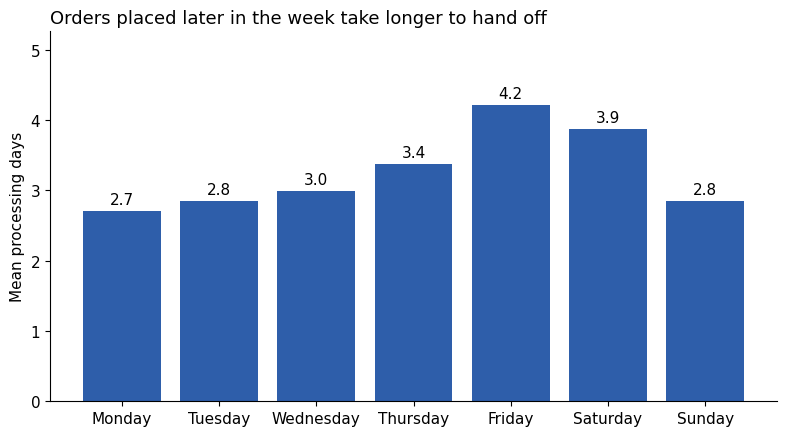

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(weekday_processing.index, weekday_processing.values, color=ACCENT)
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Mean processing days")
ax.set_title("Orders placed later in the week take longer to hand off", fontsize=13, loc="left")
ax.set_ylim(0, weekday_processing.max() * 1.25)
plt.tight_layout()
plt.show()

**Finding:** processing time creeps up toward the end of the week (Friday 4.2 days vs. Monday 2.7 days) possibly a weekend backlog, since orders placed Thursday/Friday may sit until the next business week before being handed to a carrier.

- Modest in size, but genuinely actionable: unlike transport time, this is squarely within the marketplace's operational control (e.g. weekend processing incentives or staffing) and doesn't require negotiating with an external carrier.

## Distance vs. delivery outcome

In [25]:
delivered["distance_bucket"] = pd.qcut(delivered["distance_km"], q=6, duplicates="drop")
distance_outcome = delivered.groupby("distance_bucket", observed=True).agg(
    late_rate=("is_late", "mean"), delivery_days=("delivery_days", "mean"), n=("order_id", "count")
)
distance_outcome

,late_rate,delivery_days,n
distance_bucket,,,
"(-0.001, 85.446]",0.063184,6.384478,16001
"(85.446, 305.188]",0.065062,9.756670,16000
"(305.188, 433.773]",0.077245,12.374857,16001
"(433.773, 626.806]",0.079183,13.061583,16001
"(626.806, 963.081]",0.085698,14.736837,15998
"(963.081, 3398.486]",0.115562,18.978338,16000


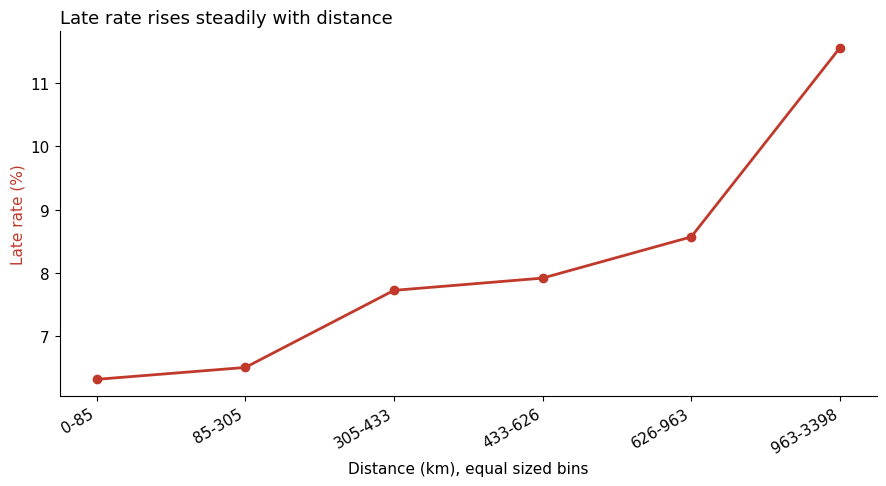

In [26]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(distance_outcome))
ax1.plot(x_pos, distance_outcome["late_rate"] * 100, marker="o", color=ACCENT_WARN, linewidth=2)
ax1.set_ylabel("Late rate (%)", color=ACCENT_WARN)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([f"{int(iv.left)}-{int(iv.right)}" for iv in distance_outcome.index], rotation=30, ha="right")
ax1.set_xlabel("Distance (km), equal sized bins")
ax1.set_title("Late rate rises steadily with distance", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** late rate rises fairly steadily across distance bins, from the nearest deliveries to the farthest.

- A monotonic, expected pattern that mostly explains why cross state shipping looked worse earlier (distance is very likely the mechanism underneath the same state/cross state split, not a separate effect).

- A single y-axis is used here (not a dual axis) since there's only one variable being tracked across distance.

## Summary

1. Cross state shipping is slower and less reliable than same state and distance appears to be the actual mechanism behind that gap.
2. Risk is concentrated in specific, nameable seller state to customer state routes (worst ones running 30 to 55% late), not evenly spread across all cross state shipping.
3. Seller performance genuinely varies on two independent axes (speed, reliability) so it is worth screening sellers on both, not collapsing into one score.
4. Southeast state order volume dominates and also has the best late rates; smaller northern states have both less volume and worse reliability.
5. State averages hide real internal spread as which seller matters within a state, not just which state.
6. A modest, controllable operational pattern exists (weekday processing creep) that's a genuinely different kind of lever than anything carrier related.